# **Sales Forecasting Using ARIMA**

## **Import Required Libraries**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

## **Read the Dataset**

In [2]:
df = pd.read_excel("Sales_Forecasting_Codec.xlsx")

df.head()

,Date,StoreID,Region,Category,Product,SalesRep,UnitsSold,UnitPrice,DiscountPercent,Revenue,Cost,Profit,Promotion,Holiday,CustomerFootfall,Inventory,StockOut,CustomerRating
0,2021-01-01,1,South,Office Supplies,Laptop,REP025,217,410.76,20,71307.94,57517.13,13790.81,No,No,285,1145,No,2
1,2021-01-01,2,South,Technology,Mouse,REP001,130,666.81,0,86685.30,72444.12,14241.18,No,No,203,240,Yes,1
2,2021-01-01,3,South,Office Supplies,Mouse,REP007,121,255.64,0,30932.44,19599.06,11333.38,Yes,No,280,183,Yes,3
3,2021-01-01,4,North,Technology,Phone,REP001,267,243.20,15,55194.24,45541.42,9652.82,Yes,No,326,1387,Yes,1
4,2021-01-01,5,East,Office Supplies,Keyboard,REP003,151,274.46,10,37299.11,30248.02,7051.09,No,No,213,923,Yes,2


## **Dataset Information**

In [3]:
df.shape

(14610, 18)

In [4]:
df.columns

Index(['Date', 'StoreID', 'Region', 'Category', 'Product', 'SalesRep',
       'UnitsSold', 'UnitPrice', 'DiscountPercent', 'Revenue', 'Cost',
       'Profit', 'Promotion', 'Holiday', 'CustomerFootfall', 'Inventory',
       'StockOut', 'CustomerRating'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14610 entries, 0 to 14609
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              14610 non-null  object 
 1   StoreID           14610 non-null  int64  
 2   Region            14610 non-null  object 
 3   Category          14610 non-null  object 
 4   Product           14610 non-null  object 
 5   SalesRep          14610 non-null  object 
 6   UnitsSold         14610 non-null  int64  
 7   UnitPrice         14610 non-null  float64
 8   DiscountPercent   14610 non-null  int64  
 9   Revenue           14610 non-null  float64
 10  Cost              14610 non-null  float64
 11  Profit            14610 non-null  float64
 12  Promotion         14610 non-null  object 
 13  Holiday           14610 non-null  object 
 14  CustomerFootfall  14610 non-null  int64  
 15  Inventory         14610 non-null  int64  
 16  StockOut          14610 non-null  object

In [6]:
df.describe()

,StoreID,UnitsSold,UnitPrice,DiscountPercent,Revenue,Cost,Profit,CustomerFootfall,Inventory,CustomerRating
count,14610.00000,14610.000000,14610.000000,14610.000000,14610.000000,14610.000000,14610.000000,14610.000000,14610.000000,14610.000000
mean,5.50000,138.987201,405.725874,12.471253,49426.836034,34551.649687,14875.186347,238.500821,788.479740,2.994798
std,2.87238,71.568271,226.338316,8.523724,40679.665917,28883.536375,13507.616846,85.729630,411.193004,1.412897
min,1.00000,10.000000,15.070000,0.000000,234.920000,151.060000,52.770000,31.000000,80.000000,1.000000
25%,3.00000,78.000000,210.360000,5.000000,16467.837500,11263.437500,4577.327500,176.000000,430.000000,2.000000
50%,5.50000,139.000000,404.455000,10.000000,38676.565000,26807.000000,10866.295000,240.000000,788.000000,3.000000
75%,8.00000,199.000000,598.867500,20.000000,73034.247500,51076.852500,21294.797500,302.000000,1145.000000,4.000000
max,10.00000,310.000000,800.000000,25.000000,224895.000000,164041.460000,84292.610000,474.000000,1500.000000,5.000000


In [7]:
df.isnull().sum()

,0
Date,0
StoreID,0
Region,0
Category,0
Product,0
SalesRep,0
UnitsSold,0
UnitPrice,0
DiscountPercent,0
Revenue,0


## **Data Preprocessing**

In [8]:
df["Date"] = pd.to_datetime(df["Date"])

In [9]:
df = df.sort_values("Date")

In [10]:
sales = df.groupby("Date")["Revenue"].sum()

sales.head()

,Revenue
Date,
2021-01-01,581958.40
2021-01-02,381088.82
2021-01-03,543573.73
2021-01-04,400590.56
2021-01-05,421499.63


## **Exploratory Data Analysis (EDA)**

### **Trend Analysis**

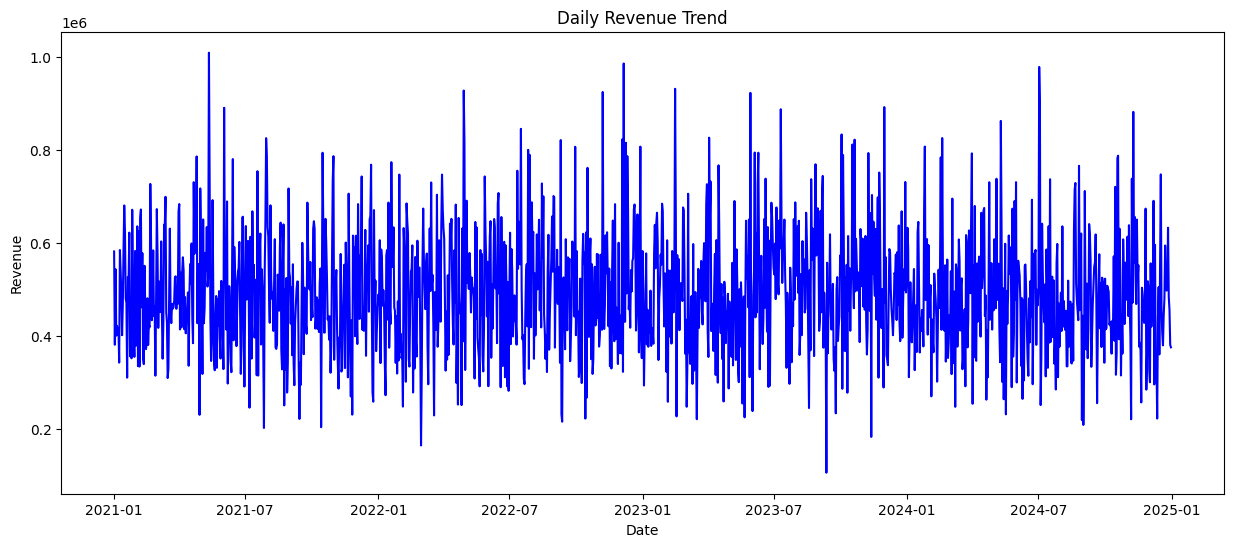

In [11]:
plt.figure(figsize=(15,6))

plt.plot(sales, color='blue')

plt.title("Daily Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")

plt.show()

### **Seasonal Analysis**

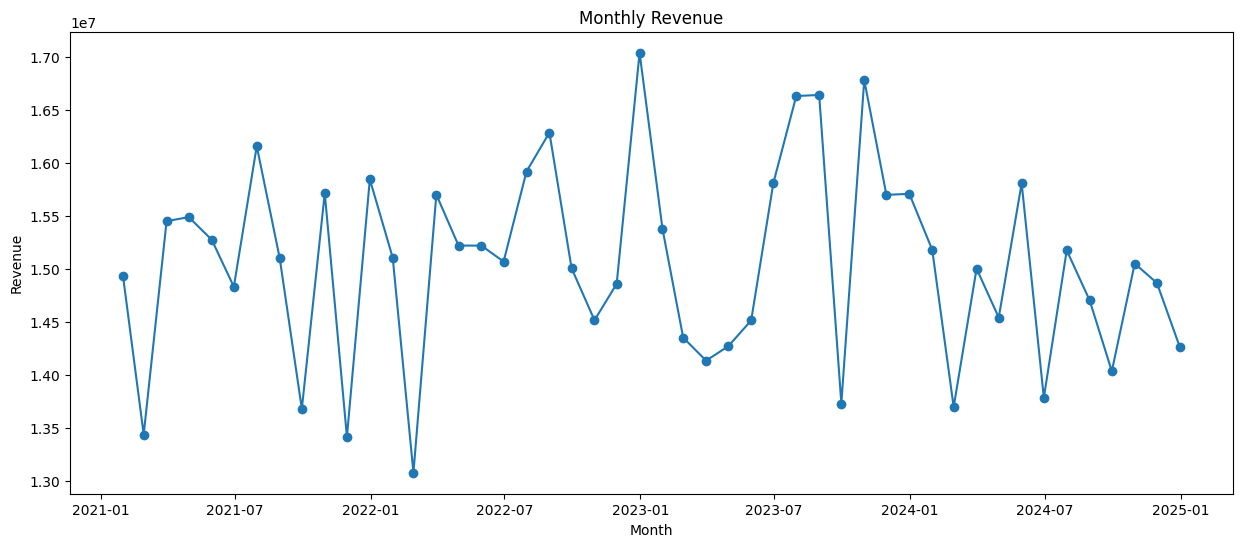

In [12]:
monthly_sales = sales.resample("ME").sum()

plt.figure(figsize=(15,6))

plt.plot(monthly_sales, marker='o')

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

### **Promotion Analysis**

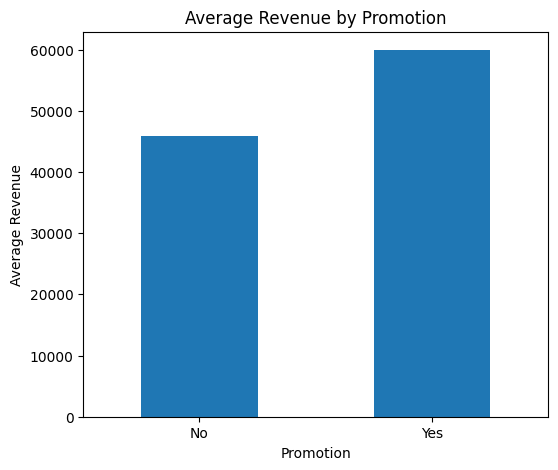

In [13]:
promo_sales = df.groupby("Promotion")["Revenue"].mean()

plt.figure(figsize=(6,5))

promo_sales.plot(kind="bar")

plt.title("Average Revenue by Promotion")
plt.xlabel("Promotion")
plt.ylabel("Average Revenue")

plt.xticks(rotation=0)

plt.show()

### **Holiday Analysis**

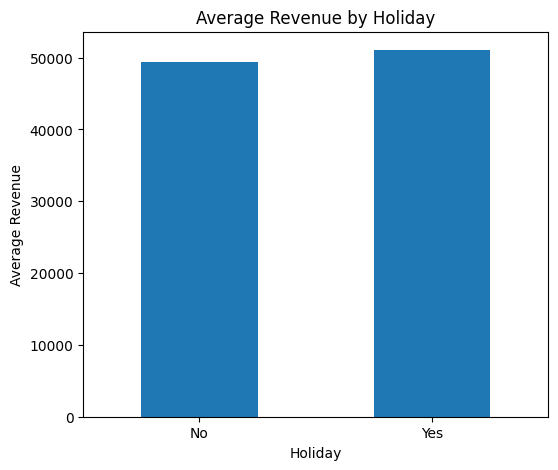

In [14]:
holiday_sales = df.groupby("Holiday")["Revenue"].mean()

plt.figure(figsize=(6,5))

holiday_sales.plot(kind="bar")

plt.title("Average Revenue by Holiday")
plt.xlabel("Holiday")
plt.ylabel("Average Revenue")

plt.xticks(rotation=0)

plt.show()

### **Revenue Distribution**

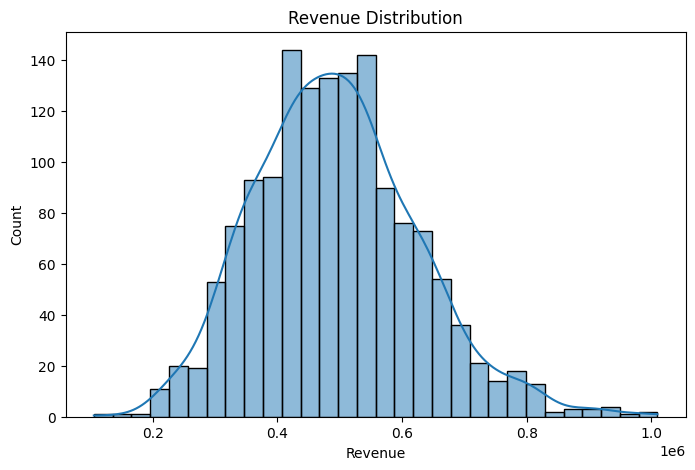

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(sales, bins=30, kde=True)

plt.title("Revenue Distribution")
plt.xlabel("Revenue")

plt.show()

## **ARIMA Model**

### **Step 1: Train-Test Split**

In [16]:
train = sales[:-30]
test = sales[-30:]

print("Training Data:", train.shape)
print("Testing Data:", test.shape)

Training Data: (1431,)
Testing Data: (30,)


### **Step 2: Build the ARIMA Model**

In [17]:
model = ARIMA(train, order=(5,1,0))

model_fit = model.fit()

### **Step 3: Forecast Future Sales**

In [18]:
forecast = model_fit.forecast(steps=30)

forecast.head()

,predicted_mean
2024-12-02,441167.384576
2024-12-03,402769.270166
2024-12-04,428464.164294
2024-12-05,437410.571134
2024-12-06,422522.520530


## **Model Evaluation**

In [19]:
mae = mean_absolute_error(test, forecast)

rmse = np.sqrt(mean_squared_error(test, forecast))

print("Mean Absolute Error (MAE):", round(mae,2))
print("Root Mean Squared Error (RMSE):", round(rmse,2))

Mean Absolute Error (MAE): 100076.93
Root Mean Squared Error (RMSE): 126881.76


## **Forecast vs Actual Sales**

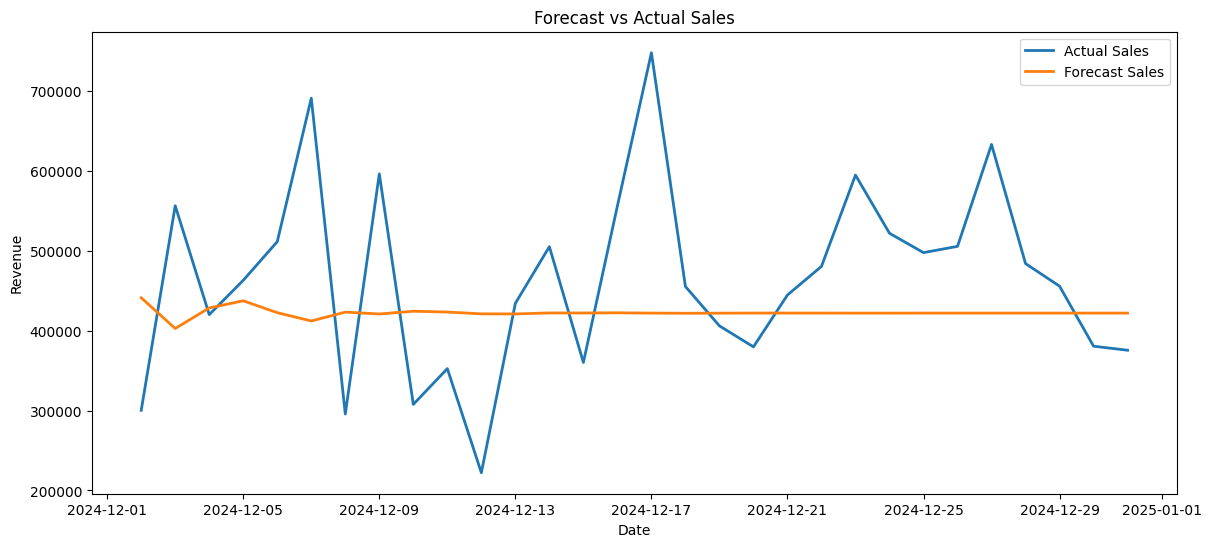

In [20]:
plt.figure(figsize=(14,6))

plt.plot(test.index, test, label="Actual Sales", linewidth=2)

plt.plot(test.index, forecast, label="Forecast Sales", linewidth=2)

plt.title("Forecast vs Actual Sales")
plt.xlabel("Date")
plt.ylabel("Revenue")

plt.legend()

plt.show()

## **Conclusion**

- This project used historical sales data to forecast future revenue using the ARIMA time-series forecasting model.

- The dataset was analyzed to identify trend, seasonal, and promotional patterns before building the forecasting model. The model's performance was evaluated using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).

- The forecast was compared with the actual sales values to visualize the model's predictive performance.